In [8]:
import pandas as pd
from statsmodels.tsa.api import VARMAX
from statsmodels.tsa.api import ARIMA
from hmmlearn import hmm
from collections import Counter
from matplotlib import pyplot as plt

#### Goals

- figure out how many unique fruits are represented (22)
- figure out how many weeks are missing data for each fruit
- fill in data with averages or drop as needed

In [9]:
produce_dataset = pd.read_csv("ProductPriceIndex.csv")

In [10]:
print(produce_dataset.columns)

# preliminary cleaning, convert "date" column to datetime
produce_dataset["date"] = pd.to_datetime(produce_dataset["date"])

# convert prices to numeric
price_columns = ['farmprice', 'atlantaretail', 'chicagoretail', 'losangelesretail', 'newyorkretail']
for col in price_columns:   # got help from AI to get rid of the $ and conver to float
    produce_dataset[col] = produce_dataset[col].str.replace("$", "").pipe(pd.to_numeric, errors="coerce")

Index(['productname', 'date', 'farmprice', 'atlantaretail', 'chicagoretail',
       'losangelesretail', 'newyorkretail', 'averagespread'],
      dtype='str')


In [11]:
# now check for nan values
produce_dataset.isna().sum()

productname         0
date                0
farmprice           1
atlantaretail       1
chicagoretail       0
losangelesretail    0
newyorkretail       8
averagespread       0
dtype: int64

In [12]:
unique_fruits = list(set(produce_dataset["productname"]))
print(len(unique_fruits), unique_fruits)

22 ['Broccoli Bunches', 'Thompson Grapes', 'Broccoli Crowns', 'Green Leaf Lettuce', 'Cantaloupe', 'Red Leaf Lettuce', 'Potatoes', 'Flame Grapes', 'Plums', 'Celery', 'Iceberg Lettuce', 'Honeydews', 'Strawberries', 'Peaches', 'Tomatoes', 'Cauliflower', 'Romaine Lettuce', 'Asparagus', 'Carrots', 'Nectarines', 'Avocados', 'Oranges']


In [13]:
# group by fruit
by_fruit = produce_dataset.groupby("productname")["date"]
print(f"Maximum dates for which data is collected: {max(by_fruit.nunique())}")
print(f"Number of fruits with over 800 days recorded: {sum(by_fruit.nunique() > 800)}")
print(by_fruit.nunique().sort_values()[::-1])

mask = by_fruit.nunique() > 800
print(min(by_fruit.apply(set)[mask]["Broccoli Crowns"]))
print(max(by_fruit.apply(set)[mask]["Broccoli Crowns"]))

Maximum dates for which data is collected: 1011
Number of fruits with over 800 days recorded: 12
productname
Broccoli Crowns       1011
Green Leaf Lettuce    1010
Iceberg Lettuce       1010
Cauliflower           1010
Red Leaf Lettuce      1009
Romaine Lettuce       1008
Celery                1007
Carrots               1007
Strawberries           969
Broccoli Bunches       968
Potatoes               848
Oranges                842
Avocados               706
Cantaloupe             499
Flame Grapes           485
Honeydews              458
Tomatoes               457
Peaches                316
Nectarines             298
Thompson Grapes        274
Asparagus              258
Plums                  235
Name: date, dtype: int64
1999-10-24 00:00:00
2019-05-19 00:00:00


Text(0, 0.5, 'Number of Fruits')

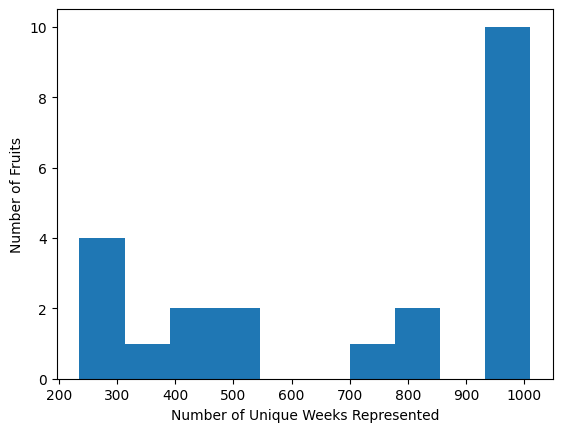

In [14]:
by_fruit.nunique().hist(grid=False)
plt.xlabel("Number of Unique Weeks Represented")
plt.ylabel("Number of Fruits")

In [15]:
# use pivot_table to get table with NaN for missing dates
pivot = produce_dataset.pivot_table(index="date", columns="productname", values='newyorkretail')
(pivot.isna().sum() / len(pivot.index)).sort_values()

productname
Broccoli Crowns       0.008832
Cauliflower           0.008832
Green Leaf Lettuce    0.008832
Iceberg Lettuce       0.009814
Carrots               0.011776
Celery                0.011776
Red Leaf Lettuce      0.011776
Romaine Lettuce       0.012758
Broccoli Bunches      0.050049
Strawberries          0.050049
Potatoes              0.167812
Oranges               0.173700
Avocados              0.307164
Cantaloupe            0.510304
Flame Grapes          0.524043
Honeydews             0.550540
Tomatoes              0.551521
Peaches               0.689892
Nectarines            0.707556
Thompson Grapes       0.732090
Asparagus             0.746811
Plums                 0.769382
dtype: float64

Since there are less than $5\%$ `NaN` for each product, we will keep all of them.

In [16]:
# print(produce_dataset.pivot_table(index="date", columns="productname", values="newyorkretail").isna().sum())

# fill nan values for each price index with linear interpolation
# cobbled together from AI assistance and my own intuition
new_dataframe = pd.DataFrame()
for col in price_columns:
    filled = produce_dataset.pivot_table(index='date', columns='productname', values=col).interpolate(axis=0).ffill().bfill()
    melted = filled.reset_index().melt(id_vars='date', var_name='productname', value_name=col)
    if col == price_columns[0]:  # only need to set these once
        new_dataframe.index = melted.index
        new_dataframe["productname"] = melted["productname"]
        new_dataframe["date"] = melted["date"]
        
    # set the rest of the columns every time
    new_dataframe[col] = melted[col]

print(new_dataframe.pivot_table(index="date", columns="productname", values="newyorkretail").isna().sum())
# it looks like it worked, there aren't any NaN values anymore

productname
Asparagus             0
Avocados              0
Broccoli Bunches      0
Broccoli Crowns       0
Cantaloupe            0
Carrots               0
Cauliflower           0
Celery                0
Flame Grapes          0
Green Leaf Lettuce    0
Honeydews             0
Iceberg Lettuce       0
Nectarines            0
Oranges               0
Peaches               0
Plums                 0
Potatoes              0
Red Leaf Lettuce      0
Romaine Lettuce       0
Strawberries          0
Thompson Grapes       0
Tomatoes              0
dtype: int64


In [17]:
print(len(produce_dataset["averagespread"]))
print(len(new_dataframe["newyorkretail"]))

15766
22418


In [18]:
# average over the cities
new_dataframe["averageretail"] = (new_dataframe["newyorkretail"] + new_dataframe["atlantaretail"] + new_dataframe["losangelesretail"] + new_dataframe["chicagoretail"]) / 4
new_dataframe["averageretail"]

0        2.8125
1        2.8125
2        2.8125
3        2.8125
4        2.8125
          ...  
22413    1.4700
22414    1.4700
22415    1.4700
22416    1.4700
22417    1.4700
Name: averageretail, Length: 22418, dtype: float64

In [19]:
# convert cleaned data to csv
new_dataframe.to_csv("cleaned_produce.csv")

Cleaning Stock Data

In [20]:
sp_dataset = pd.read_csv('SPX.csv')

# convert dates to date_time type for pandas
produce_dataset['date'] = pd.to_datetime(produce_dataset['date'])
sp_dataset['Date'] = pd.to_datetime(sp_dataset['Date'])

# pull dates (sundays) from fruit data to get a list of mondays for stocks
mondays = pd.to_datetime(produce_dataset['date']) + pd.DateOffset(days=1)
mondays = mondays.unique()

# keep only monday opening prices from sp_dataset
sp_mondays = sp_dataset[sp_dataset['Date'].isin(mondays)]
sp_timeseries = sp_mondays[['Date', 'Open']]
sp_timeseries.to_csv('cleaned_sp.csv')